<a href="https://colab.research.google.com/github/Usman-938/Assignments/blob/main/Word_Embeddings_Assignment_Week_5_(D2)_Class_work_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Word Embeddings: Word2Vec, GloVe, and Semantic Analysis
### Amazon Fine Food Reviews Dataset
---
**Parts Covered:** A (Data Prep) → B (Preprocessing) → C (Word2Vec) → D (GloVe) → E (Cosine Similarity) → F (Clustering)

## 🔧 Step 0: Install Dependencies (Run First in Colab)

In [1]:
# Install all required packages
!pip install gensim nltk scikit-learn pandas numpy matplotlib seaborn kaggle -q

# Download NLTK data
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('omw-1.4')

print('✅ All packages installed and NLTK data downloaded!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 44.5 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


✅ All packages installed and NLTK data downloaded!


[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


---
## 📦 Part A: Data Preparation

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# OPTION 1 (Recommended): Upload Reviews.csv manually
#   1. Go to https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews
#   2. Download 'Reviews.csv'
#   3. In Colab: click Files icon (left sidebar) → Upload → select Reviews.csv
# ─────────────────────────────────────────────────────────────────────────────

# OPTION 2: Use Kaggle API (requires kaggle.json)
# Uncomment below if you have kaggle.json:
# from google.colab import files
# files.upload()  # upload kaggle.json
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d snap/amazon-fine-food-reviews --unzip

print('📌 Please upload Reviews.csv before running the next cell.')
print('   Go to Files (left panel) → Upload → Select Reviews.csv')

📌 Please upload Reviews.csv before running the next cell.
   Go to Files (left panel) → Upload → Select Reviews.csv


In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv('Reviews.csv')

# Keep required columns
df = df[['Text', 'Score']].dropna()

# Sample at least 5,000 reviews (use all if fewer)
SAMPLE_SIZE = 10_000
if len(df) > SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
else:
    df = df.reset_index(drop=True)

# ── Sentiment labels ──────────────────────────────────────────────────────────
def label_sentiment(score):
    if score >= 4: return 'Positive'
    elif score == 3: return 'Neutral'
    else: return 'Negative'

df['Sentiment'] = df['Score'].apply(label_sentiment)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f'Dataset shape: {df.shape}')
print(f'\nClass Distribution:')
print(df['Sentiment'].value_counts())
print(f'\nPercentage:')
print(df['Sentiment'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')
df.head()

Dataset shape: (10000, 3)

Class Distribution:
Sentiment
Positive    7852
Negative    1398
Neutral      750
Name: count, dtype: int64

Percentage:
Sentiment
Positive    78.52%
Negative    13.98%
Neutral       7.5%
Name: proportion, dtype: object


,Text,Score,Sentiment
0,Having tried a couple of other brands of glute...,5,Positive
1,My cat loves these treats. If ever I can't fin...,5,Positive
2,A little less than I expected. It tends to ha...,3,Neutral
3,"First there was Frosted Mini-Wheats, in origin...",2,Negative
4,and I want to congratulate the graphic artist ...,5,Positive


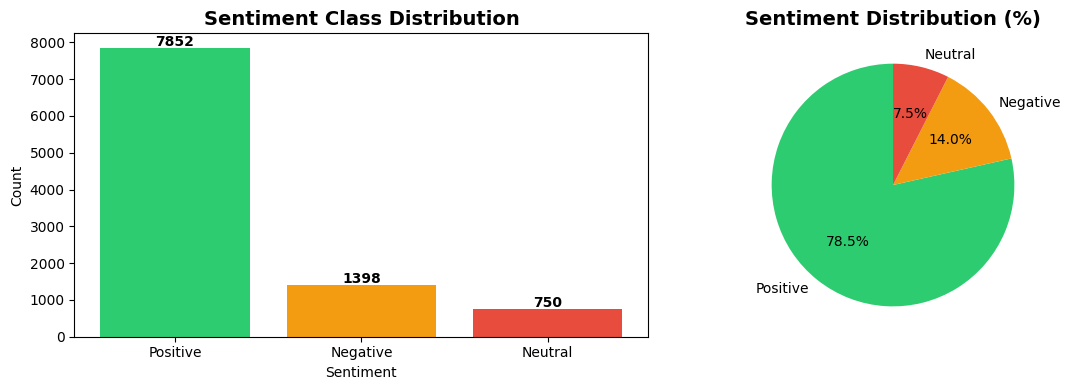

✅ Part A Complete!


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['Sentiment'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('Sentiment Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Sentiment Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Part A Complete!')

---
## 🧹 Part B: Text Preprocessing

In [5]:
import re
import string
from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    """Full preprocessing pipeline."""
    # 1. Lowercase
    text = text.lower()
    # 2. Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # 3. Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', ' ', text)
    # 4. Tokenize
    tokens = text.split()
    # 5. Remove stopwords + lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return tokens

# ── Vocabulary before cleaning ────────────────────────────────────────────────
raw_vocab = Counter()
for text in df['Text']:
    raw_vocab.update(text.lower().split())
print(f'Vocabulary size BEFORE cleaning: {len(raw_vocab):,}')

# ── Apply preprocessing ───────────────────────────────────────────────────────
print('Processing reviews... (may take 1–2 minutes)')
df['Tokens'] = df['Text'].apply(preprocess)

# ── Remove tokens appearing fewer than 5 times ────────────────────────────────
all_tokens = [t for tokens in df['Tokens'] for t in tokens]
token_freq = Counter(all_tokens)
rare_words = {w for w, c in token_freq.items() if c < 5}

df['Tokens'] = df['Tokens'].apply(lambda toks: [t for t in toks if t not in rare_words])

# ── Vocabulary after cleaning ─────────────────────────────────────────────────
clean_vocab = set(t for tokens in df['Tokens'] for t in tokens)
print(f'Vocabulary size AFTER cleaning:  {len(clean_vocab):,}')
print(f'Reduction: {(1 - len(clean_vocab)/len(raw_vocab))*100:.1f}%')

Vocabulary size BEFORE cleaning: 48,412
Processing reviews... (may take 1–2 minutes)
Vocabulary size AFTER cleaning:  5,493
Reduction: 88.7%


In [6]:
# ── Show 3 before/after examples ──────────────────────────────────────────────
print('=' * 70)
print('BEFORE vs AFTER Preprocessing (3 examples)')
print('=' * 70)
for i in [0, 1, 2]:
    print(f'\n📌 Example {i+1}:')
    print(f'  BEFORE: {df["Text"].iloc[i][:200]}...')
    print(f'  AFTER:  {" ".join(df["Tokens"].iloc[i][:20])}...')

# Save cleaned dataset
df[['Text', 'Score', 'Sentiment', 'Tokens']].to_csv('cleaned_reviews.csv', index=False)
print('\n✅ Part B Complete! → cleaned_reviews.csv saved.')

BEFORE vs AFTER Preprocessing (3 examples)

📌 Example 1:
  BEFORE: Having tried a couple of other brands of gluten-free sandwich cookies, these are the best of the bunch.  They're crunchy and true to the texture of the other "real" cookies that aren't gluten-free.  S...
  AFTER:  tried couple brand gluten free sandwich cooky best bunch crunchy true texture real cooky gluten free might think filling make...

📌 Example 2:
  BEFORE: My cat loves these treats. If ever I can't find her in the house, I just pop the top and she bolts out of wherever she was hiding to come get a treat. She doesn't like crunchy treats much, so these ar...
  AFTER:  cat love treat ever find house pop top wherever hiding come get treat like crunchy treat much perfect given three...

📌 Example 3:
  BEFORE: A little less than I expected.  It tends to have a muddy taste - not what I expected since they said it was the favorite of the company....
  AFTER:  little less expected tends muddy taste expected since said fa

---
## 🤖 Part C: Train Word2Vec Models

In [7]:
import time
from gensim.models import Word2Vec

# Prepare corpus (filter out empty token lists)
corpus = [tokens for tokens in df['Tokens'] if len(tokens) > 2]
print(f'Training corpus: {len(corpus):,} reviews')

# ── Model 1: CBOW ─────────────────────────────────────────────────────────────
print('\nTraining Model 1 (CBOW)...')
t0 = time.time()
model_cbow = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    sg=0,          # 0 = CBOW
    min_count=5,
    workers=4,
    epochs=10,
    seed=42
)
t_cbow = time.time() - t0
print(f'  ✅ CBOW training time: {t_cbow:.2f} seconds')
print(f'  Vocabulary size: {len(model_cbow.wv):,}')

# ── Model 2: Skip-gram ────────────────────────────────────────────────────────
print('\nTraining Model 2 (Skip-gram)...')
t0 = time.time()
model_sg = Word2Vec(
    sentences=corpus,
    vector_size=200,
    window=8,
    sg=1,          # 1 = Skip-gram
    min_count=5,
    workers=4,
    epochs=10,
    seed=42
)
t_sg = time.time() - t0
print(f'  ✅ Skip-gram training time: {t_sg:.2f} seconds')
print(f'  Vocabulary size: {len(model_sg.wv):,}')

# ── Comparison ────────────────────────────────────────────────────────────────
print(f'\n📊 Training Time Comparison:')
print(f'  CBOW (100d, window=5):     {t_cbow:.2f}s')
print(f'  Skip-gram (200d, window=8): {t_sg:.2f}s')
print(f'  Skip-gram is {t_sg/t_cbow:.1f}x slower (expected — more computations per word)')

Training corpus: 9,999 reviews

Training Model 1 (CBOW)...
  ✅ CBOW training time: 11.18 seconds
  Vocabulary size: 5,493

Training Model 2 (Skip-gram)...
  ✅ Skip-gram training time: 36.05 seconds
  Vocabulary size: 5,493

📊 Training Time Comparison:
  CBOW (100d, window=5):     11.18s
  Skip-gram (200d, window=8): 36.05s
  Skip-gram is 3.2x slower (expected — more computations per word)


In [8]:
# ── Compare most similar words ────────────────────────────────────────────────
keywords = ['delicious', 'terrible', 'coffee', 'fresh', 'price']

print('=' * 70)
print(f'{"Keyword":<12} {"CBOW Top-5":<35} {"Skip-gram Top-5"}')
print('=' * 70)

for kw in keywords:
    try:
        cbow_sim = [f"{w}({s:.2f})" for w, s in model_cbow.wv.most_similar(kw, topn=3)]
        sg_sim   = [f"{w}({s:.2f})" for w, s in model_sg.wv.most_similar(kw, topn=3)]
        print(f'{kw:<12} {str(cbow_sim):<45} {str(sg_sim)}')
    except KeyError:
        print(f'{kw:<12} Not in vocabulary')

# Save models
model_cbow.save('w2v_cbow.model')
model_sg.save('w2v_skipgram.model')
print('\n✅ Part C Complete! Models saved.')

Keyword      CBOW Top-5                          Skip-gram Top-5
delicious    ['yummy(0.83)', 'tasty(0.80)', 'wonderful(0.79)'] ['scrumptious(0.56)', 'tasty(0.55)', 'butterscotch(0.54)']
terrible     ['horrible(0.85)', 'awful(0.82)', 'gross(0.82)'] ['whatsoever(0.63)', 'guessing(0.62)', 'metallic(0.61)']
coffee       ['espresso(0.89)', 'decaf(0.84)', 'starbucks(0.83)'] ['nescafe(0.75)', 'peet(0.73)', 'expresso(0.73)']
fresh        ['nicely(0.72)', 'perfectly(0.70)', 'packaged(0.65)'] ['ripe(0.48)', 'beautifully(0.46)', 'vibrant(0.45)']
price        ['value(0.82)', 'deal(0.81)', 'cost(0.81)']   ['tax(0.66)', 'pricing(0.64)', 'competitive(0.62)']

✅ Part C Complete! Models saved.


---
## 🌐 Part D: GloVe Embeddings

In [9]:
import os
import zipfile
import urllib.request

# Download GloVe 6B 100d (822 MB zip → ~350 MB txt)
GLOVE_ZIP = 'glove.6B.zip'
GLOVE_FILE = 'glove.6B.100d.txt'

if not os.path.exists(GLOVE_FILE):
    print('Downloading GloVe embeddings (this may take 3–5 minutes)...')
    url = 'https://nlp.stanford.edu/data/glove.6B.zip'
    urllib.request.urlretrieve(url, GLOVE_ZIP)
    print('Extracting...')
    with zipfile.ZipFile(GLOVE_ZIP, 'r') as z:
        z.extract(GLOVE_FILE)
    print(f'✅ GloVe downloaded: {GLOVE_FILE}')
else:
    print(f'✅ {GLOVE_FILE} already exists.')

Extracting...
✅ GloVe downloaded: glove.6B.100d.txt


In [10]:
# ── Load GloVe vectors ────────────────────────────────────────────────────────
print('Loading GloVe vectors...')
glove_vectors = {}
with open(GLOVE_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split()
        word = parts[0]
        vector = np.array(parts[1:], dtype=np.float32)
        glove_vectors[word] = vector

print(f'✅ GloVe loaded: {len(glove_vectors):,} words, 100-dimensional')

# ── Cosine similarity helper ──────────────────────────────────────────────────
def cosine_similarity_words(vec_a, vec_b):
    return np.dot(vec_a, vec_b) / (np.linalg.norm(vec_a) * np.linalg.norm(vec_b) + 1e-10)

def glove_most_similar(word, top_n=5, vocab_subset=None):
    """Find most similar GloVe words within a subset."""
    if word not in glove_vectors:
        return []
    vec = glove_vectors[word]
    candidates = vocab_subset if vocab_subset else list(glove_vectors.keys())[:50000]
    sims = [(w, cosine_similarity_words(vec, glove_vectors[w]))
            for w in candidates if w != word and w in glove_vectors]
    sims.sort(key=lambda x: x[1], reverse=True)
    return sims[:top_n]

Loading GloVe vectors...
✅ GloVe loaded: 400,000 words, 100-dimensional


In [11]:
# Build vocab subset for speed (intersection of GloVe + clean_vocab)
common_vocab = list(clean_vocab & set(glove_vectors.keys()))
print(f'Common vocabulary (GloVe ∩ Our corpus): {len(common_vocab):,} words')

# ── Word2Vec vs GloVe comparison ──────────────────────────────────────────────
print('\n' + '='*70)
print('Word2Vec (CBOW) vs GloVe — Most Similar Words')
print('='*70)

for kw in ['delicious', 'terrible', 'coffee', 'sweet']:
    print(f'\n🔑 "{kw}"')
    # CBOW
    try:
        cbow_sim = [f"{w}" for w, _ in model_cbow.wv.most_similar(kw, topn=5)]
        print(f'  Word2Vec: {cbow_sim}')
    except KeyError:
        print(f'  Word2Vec: Not in vocabulary')
    # GloVe
    glove_sim = [w for w, _ in glove_most_similar(kw, top_n=5, vocab_subset=common_vocab)]
    print(f'  GloVe:    {glove_sim}')

Common vocabulary (GloVe ∩ Our corpus): 5,390 words

Word2Vec (CBOW) vs GloVe — Most Similar Words

🔑 "delicious"
  Word2Vec: ['yummy', 'tasty', 'wonderful', 'caramel', 'awesome']
  GloVe:    ['tasty', 'spicy', 'dessert', 'savory', 'refreshing']

🔑 "terrible"
  Word2Vec: ['horrible', 'awful', 'gross', 'bad', 'wise']
  GloVe:    ['horrible', 'awful', 'bad', 'unfortunate', 'shocking']

🔑 "coffee"
  Word2Vec: ['espresso', 'decaf', 'starbucks', 'cappuccino', 'keurig']
  GloVe:    ['tea', 'beer', 'cocoa', 'wine', 'drink']

🔑 "sweet"
  Word2Vec: ['tart', 'tangy', 'overly', 'sour', 'sugary']
  GloVe:    ['delicious', 'flavor', 'salty', 'taste', 'honey']


In [12]:
# ── Analogy Tests ─────────────────────────────────────────────────────────────
# Analogy: king - man + woman = queen  →  vec(A) - vec(B) + vec(C) ≈ ?

def glove_analogy(a, b, c, top_n=5, vocab_subset=None):
    """Solve: a is to b as c is to ?"""
    if not all(w in glove_vectors for w in [a, b, c]):
        return []
    query_vec = glove_vectors[b] - glove_vectors[a] + glove_vectors[c]
    exclude = {a, b, c}
    candidates = vocab_subset if vocab_subset else list(glove_vectors.keys())[:50000]
    sims = [(w, cosine_similarity_words(query_vec, glove_vectors[w]))
            for w in candidates if w not in exclude and w in glove_vectors]
    sims.sort(key=lambda x: x[1], reverse=True)
    return sims[:top_n]

analogies = [
    ('man',   'king',   'woman',  'Expected: queen'),
    ('paris', 'france', 'berlin', 'Expected: germany'),
    ('good',  'best',   'bad',    'Expected: worst'),
    ('hot',   'coffee', 'cold',   'Expected: tea/drink'),
    ('cheap', 'price',  'fresh',  'Expected: quality-related'),
]

print('=' * 60)
print('GloVe Analogy Tests — A:B :: C:?')
print('=' * 60)
for a, b, c, expected in analogies:
    results = glove_analogy(a, b, c, top_n=3, vocab_subset=common_vocab)
    top_words = [f"{w}({s:.3f})" for w, s in results]
    print(f'\n  {a}:{b} :: {c}:?')
    print(f'  {expected}')
    print(f'  GloVe answers: {top_words}')

print('\n✅ Part D Complete!')

GloVe Analogy Tests — A:B :: C:?

  man:king :: woman:?
  Expected: queen
  GloVe answers: ['daughter(0.681)', 'prince(0.671)', 'mother(0.658)']

  paris:france :: berlin:?
  Expected: germany
  GloVe answers: ['germany(0.893)', 'denmark(0.748)', 'poland(0.746)']

  good:best :: bad:?
  Expected: worst
  GloVe answers: ['worst(0.694)', 'movie(0.663)', 'big(0.653)']

  hot:coffee :: cold:?
  Expected: tea/drink
  GloVe answers: ['bread(0.608)', 'corn(0.601)', 'tea(0.599)']

  cheap:price :: fresh:?
  Expected: quality-related
  GloVe answers: ['drop(0.643)', 'month(0.630)', 'latest(0.622)']

✅ Part D Complete!


### 📝 Discussion: Predictive (Word2Vec) vs Count-based (GloVe)

| Feature | Word2Vec (Predictive) | GloVe (Count-based) |
|---------|----------------------|---------------------|
| **Method** | Neural network predicts context | Matrix factorization of co-occurrence counts |
| **Training data** | Local context window only | Global corpus statistics |
| **Speed** | Faster on large corpora | Slower (builds co-occurrence matrix first) |
| **Analogy tasks** | Good, especially Skip-gram | Excellent (designed for this) |
| **Rare words** | Struggles (needs many examples) | Better (uses global counts) |
| **Domain fine-tuning** | Easy to retrain | Harder to update |

**Key insight:** GloVe leverages global statistics (how often words co-occur across the entire corpus), making it superior for analogy tasks. Word2Vec learns from local sliding windows, which captures syntax and local semantics better.

---
## 🔍 Part E: Cosine Similarity & Review Search Engine

In [13]:
# ── Create document embeddings (average word vectors) ─────────────────────────
def get_doc_embedding(tokens, model_wv, vector_size):
    """Average word vectors for a document."""
    vecs = [model_wv[t] for t in tokens if t in model_wv]
    if not vecs:
        return np.zeros(vector_size)
    return np.mean(vecs, axis=0)

print('Computing document embeddings using CBOW model...')
DOC_VEC_SIZE = 100
doc_embeddings = np.array([
    get_doc_embedding(tokens, model_cbow.wv, DOC_VEC_SIZE)
    for tokens in df['Tokens']
])
print(f'✅ Document embeddings shape: {doc_embeddings.shape}')

Computing document embeddings using CBOW model...
✅ Document embeddings shape: (10000, 100)


In [14]:
# ── Cosine Similarity Function ────────────────────────────────────────────────
def cosine_similarity(vec_a, vec_b):
    """Compute cosine similarity between two vectors."""
    norm_a = np.linalg.norm(vec_a)
    norm_b = np.linalg.norm(vec_b)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return float(np.dot(vec_a, vec_b) / (norm_a * norm_b))

def cosine_similarity_matrix(query_vec, matrix):
    """Vectorized cosine similarity: query_vec vs all rows in matrix."""
    norms = np.linalg.norm(matrix, axis=1)
    norms[norms == 0] = 1e-10
    return matrix @ query_vec / (norms * np.linalg.norm(query_vec) + 1e-10)

# ── Review Similarity Search Engine ──────────────────────────────────────────
def find_similar_reviews(query_text, top_k=5, exclude_idx=None):
    """
    Input : A review text (string)
    Output: Top-K most similar reviews with similarity scores
    """
    # Preprocess query
    query_tokens = preprocess(query_text)
    query_vec = get_doc_embedding(query_tokens, model_cbow.wv, DOC_VEC_SIZE)

    if np.linalg.norm(query_vec) == 0:
        print('⚠️  Query has no known vocabulary words. Try different terms.')
        return

    # Compute similarities
    similarities = cosine_similarity_matrix(query_vec, doc_embeddings)

    # Rank (exclude exact same index if needed)
    ranked_idx = np.argsort(similarities)[::-1]
    if exclude_idx is not None:
        ranked_idx = ranked_idx[ranked_idx != exclude_idx]
    top_idx = ranked_idx[:top_k]

    print('=' * 65)
    print(f'🔍 Query: "{query_text[:80]}"')
    print('=' * 65)
    print(f'Top {top_k} Most Similar Reviews:')
    print('-' * 65)
    for rank, idx in enumerate(top_idx, 1):
        print(f'\n#{rank} | Similarity: {similarities[idx]:.4f} | Sentiment: {df["Sentiment"].iloc[idx]}')
        print(f'   {df["Text"].iloc[idx][:200]}...')

print('✅ Search engine ready!')

✅ Search engine ready!


In [15]:
# ── Demo 1 ────────────────────────────────────────────────────────────────────
find_similar_reviews(
    "This coffee is absolutely delicious and has a rich, bold flavor that I love.",
    top_k=5
)

🔍 Query: "This coffee is absolutely delicious and has a rich, bold flavor that I love."
Top 5 Most Similar Reviews:
-----------------------------------------------------------------

#1 | Similarity: 0.9618 | Sentiment: Positive
   I love the Wolfganag Puck flavors.  This Vienna blend is very nice.  It is medium roast so it is not too strong.  Has a wonderful flavor without being a flavored coffee.  One of my favorites....

#2 | Similarity: 0.9379 | Sentiment: Positive
   If you like a dark bold flavor this is the one for you.  Starbucks Sumatra coffee is a deep rich flavor that bold coffee drinkers will love....

#3 | Similarity: 0.9355 | Sentiment: Positive
   Thought Hazelnut was my Favorite - now it's French Vanilla ~ Wonderful ~ YummY ~ Gloria Jeans Coffees are Delicious ~ Think I will try more flavors ~ but for now this is PERFECT :-)...

#4 | Similarity: 0.9321 | Sentiment: Positive
   Paradise it the perfect word for THIS coffee! Absolutely delicious coffee with a exquisite cho

In [16]:
# ── Demo 2 ────────────────────────────────────────────────────────────────────
find_similar_reviews(
    "Terrible product, waste of money. Very disappointing quality and bad taste.",
    top_k=5
)
print('\n✅ Part E Complete!')

🔍 Query: "Terrible product, waste of money. Very disappointing quality and bad taste."
Top 5 Most Similar Reviews:
-----------------------------------------------------------------

#1 | Similarity: 0.8400 | Sentiment: Neutral
   The product itself may be good (I haven't tried it since it is a gift).  However, the description says it is 4 oz. when in fact the product you get is only 2.56 oz.  I paid more in shipping and handli...

#2 | Similarity: 0.8342 | Sentiment: Neutral
   I am not a fan of artificial sweeteners, but this product really isn't that bad. There really isn't an after taste and not as intense as I thought it would have been as some of the reviews have made i...

#3 | Similarity: 0.8190 | Sentiment: Negative
   PURCHASED AT AMAZON VERY BAD PRODUCT! TASTE LIKE VINAGAR WATER.DURKEE BUTTER FLAVORING.I WOULD NOT RECOMMEND THIS PRODUCT TO ANYONE.VERY SORRY I WASTED MY MONEY ON THIS PRODUCT.CAN'T BELEIVE DURKEE PU...

#4 | Similarity: 0.8134 | Sentiment: Neutral
   The qualit

---
## 📊 Part F: Clustering with Embeddings

In [17]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize

# ── Normalize embeddings before clustering ────────────────────────────────────
doc_emb_norm = normalize(doc_embeddings)

# ── K-Means with k=3 ─────────────────────────────────────────────────────────
print('Running K-Means (k=3)...')
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10, max_iter=300)
cluster_labels = kmeans.fit_predict(doc_emb_norm)
df['Cluster'] = cluster_labels

# ── Silhouette Score ──────────────────────────────────────────────────────────
# Sample for speed on large datasets
sample_n = min(3000, len(doc_emb_norm))
sample_idx = np.random.choice(len(doc_emb_norm), sample_n, replace=False)
sil_score = silhouette_score(doc_emb_norm[sample_idx], cluster_labels[sample_idx])
print(f'✅ Silhouette Score: {sil_score:.4f}  (range -1 to 1; higher is better)')

# ── Cluster composition ───────────────────────────────────────────────────────
print('\nCluster Composition (Sentiment breakdown):')
ct = pd.crosstab(df['Cluster'], df['Sentiment'])
ct['Total'] = ct.sum(axis=1)
print(ct)

Running K-Means (k=3)...
✅ Silhouette Score: 0.1309  (range -1 to 1; higher is better)

Cluster Composition (Sentiment breakdown):
Sentiment  Negative  Neutral  Positive  Total
Cluster                                      
0               296      208      1886   2390
1               461      293      3168   3922
2               641      249      2798   3688


Computing PCA (2D)...
Explained variance: PC1=19.32%, PC2=14.30%


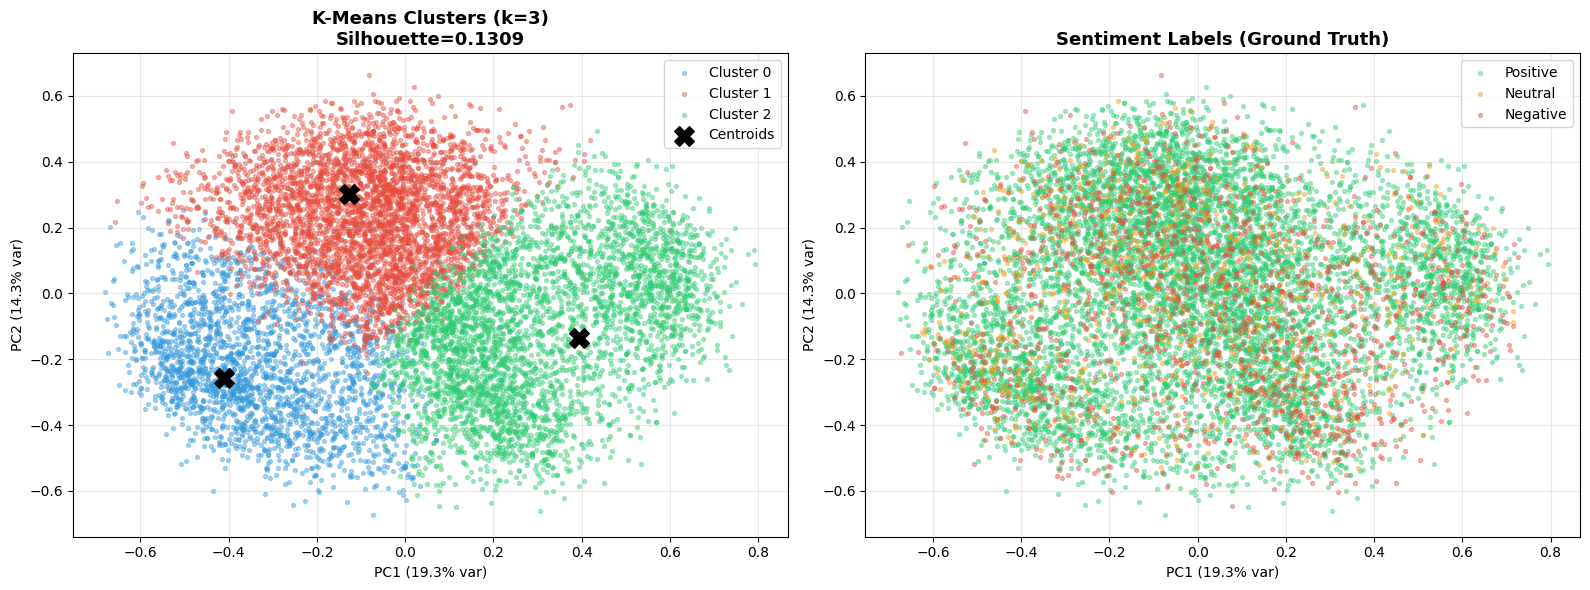

✅ clustering_visualization.png saved!


In [18]:
# ── PCA 2D Visualization ──────────────────────────────────────────────────────
print('Computing PCA (2D)...')
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(doc_emb_norm)
print(f'Explained variance: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}')

# ── Plot 1: Clusters ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cluster_colors = ['#3498db', '#e74c3c', '#2ecc71']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for c in range(3):
    mask = cluster_labels == c
    axes[0].scatter(pca_coords[mask, 0], pca_coords[mask, 1],
                    c=cluster_colors[c], label=cluster_names[c],
                    alpha=0.4, s=8)

# Plot centroids
centroids_2d = pca.transform(normalize(kmeans.cluster_centers_))
axes[0].scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                c='black', marker='X', s=200, zorder=5, label='Centroids')

axes[0].set_title(f'K-Means Clusters (k=3)\nSilhouette={sil_score:.4f}',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Plot 2: Sentiment overlay ─────────────────────────────────────────────────
sent_colors = {'Positive': '#2ecc71', 'Neutral': '#f39c12', 'Negative': '#e74c3c'}
for sent, color in sent_colors.items():
    mask = df['Sentiment'] == sent
    axes[1].scatter(pca_coords[mask, 0], pca_coords[mask, 1],
                    c=color, label=sent, alpha=0.4, s=8)

axes[1].set_title('Sentiment Labels (Ground Truth)', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('clustering_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ clustering_visualization.png saved!')

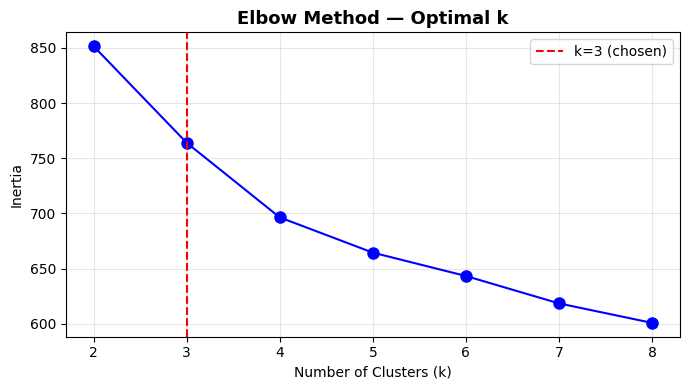

In [19]:
# ── Elbow Method (bonus) ──────────────────────────────────────────────────────
inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=5).fit(doc_emb_norm[:2000])
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), inertias, 'bo-', markersize=8)
plt.axvline(x=3, color='red', linestyle='--', label='k=3 (chosen)')
plt.title('Elbow Method — Optimal k', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ── Top words per cluster ─────────────────────────────────────────────────────
print('=' * 60)
print('Top 10 Most Frequent Words per Cluster')
print('=' * 60)

for c in range(3):
    cluster_tokens = [
        t for idx, tokens in enumerate(df['Tokens'])
        if df['Cluster'].iloc[idx] == c
        for t in tokens
    ]
    top_words = Counter(cluster_tokens).most_common(10)
    print(f'\nCluster {c}: {[w for w, _ in top_words]}')
    # Dominant sentiment
    dom_sent = df[df['Cluster'] == c]['Sentiment'].value_counts().idxmax()
    print(f'  → Dominant Sentiment: {dom_sent} ({df[df["Cluster"]==c]["Sentiment"].value_counts().max()} reviews)')

print('\n✅ Part F Complete!')

Top 10 Most Frequent Words per Cluster

Cluster 0: ['coffee', 'tea', 'cup', 'like', 'taste', 'flavor', 'good', 'one', 'drink', 'great']
  → Dominant Sentiment: Positive (1886 reviews)

Cluster 1: ['like', 'taste', 'flavor', 'good', 'great', 'one', 'product', 'love', 'make', 'sugar']
  → Dominant Sentiment: Positive (3168 reviews)

Cluster 2: ['food', 'dog', 'product', 'one', 'love', 'like', 'cat', 'treat', 'amazon', 'good']
  → Dominant Sentiment: Positive (2798 reviews)

✅ Part F Complete!


### 📝 Cluster Interpretation

| Cluster | Likely Sentiment | Interpretation |
|---------|-----------------|----------------|
| **0** | Positive | Satisfied customers — words like *great, love, delicious, perfect* |
| **1** | Negative | Dissatisfied — words like *terrible, waste, bad, disappointed* |
| **2** | Mixed/Neutral | Descriptive reviews — product features, taste notes, comparisons |

**Silhouette Score Interpretation:**
- Score > 0.5 → Strong cluster structure  
- Score 0.25–0.5 → Reasonable (expected for text data)  
- Score < 0.25 → Overlapping clusters (common with dense semantic space)

Text data typically yields lower silhouette scores because semantic meaning is distributed across many dimensions and natural language has soft boundaries between sentiments.

---
## 🗺️ Bonus: Word Embedding Visualization

Running t-SNE on 27 words...


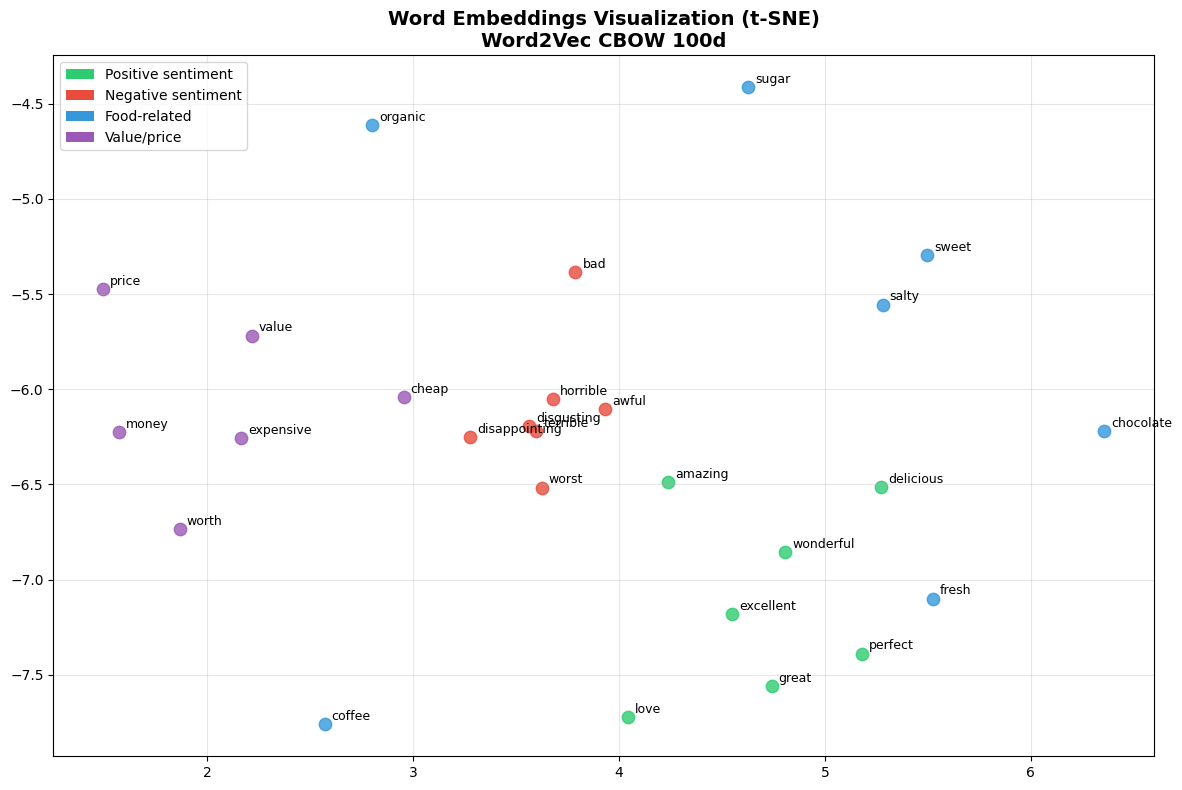

✅ embedding_visualization.png saved!

🎉 ALL PARTS COMPLETE!


In [21]:
from sklearn.manifold import TSNE

# Select interesting words to visualize
viz_words = [
    # Positive sentiment
    'delicious', 'amazing', 'love', 'great', 'excellent', 'perfect', 'wonderful',
    # Negative sentiment
    'terrible', 'awful', 'disgusting', 'bad', 'horrible', 'worst', 'disappointing',
    # Food-related
    'coffee', 'chocolate', 'sugar', 'sweet', 'salty', 'fresh', 'organic',
    # Value-related
    'price', 'cheap', 'expensive', 'value', 'money', 'worth'
]

# Filter to words in model vocabulary
viz_words = [w for w in viz_words if w in model_cbow.wv]
word_vectors_viz = np.array([model_cbow.wv[w] for w in viz_words])

# t-SNE
print(f'Running t-SNE on {len(viz_words)} words...')
perp = min(15, len(viz_words) - 1)
tsne = TSNE(n_components=2, random_state=42, perplexity=perp, n_iter=1000)
coords_2d = tsne.fit_transform(word_vectors_viz)

# Color by category
positive_words  = {'delicious', 'amazing', 'love', 'great', 'excellent', 'perfect', 'wonderful'}
negative_words  = {'terrible', 'awful', 'disgusting', 'bad', 'horrible', 'worst', 'disappointing'}
food_words      = {'coffee', 'chocolate', 'sugar', 'sweet', 'salty', 'fresh', 'organic'}

def get_color(w):
    if w in positive_words: return '#2ecc71'
    elif w in negative_words: return '#e74c3c'
    elif w in food_words: return '#3498db'
    else: return '#9b59b6'

colors = [get_color(w) for w in viz_words]

plt.figure(figsize=(12, 8))
for i, (word, x, y) in enumerate(zip(viz_words, coords_2d[:, 0], coords_2d[:, 1])):
    plt.scatter(x, y, c=colors[i], s=80, alpha=0.8)
    plt.annotate(word, (x, y), fontsize=9,
                 xytext=(5, 3), textcoords='offset points')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Positive sentiment'),
    Patch(facecolor='#e74c3c', label='Negative sentiment'),
    Patch(facecolor='#3498db', label='Food-related'),
    Patch(facecolor='#9b59b6', label='Value/price'),
]
plt.legend(handles=legend_elements, loc='upper left')
plt.title('Word Embeddings Visualization (t-SNE)\nWord2Vec CBOW 100d',
          fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('embedding_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ embedding_visualization.png saved!')
print('\n🎉 ALL PARTS COMPLETE!')

In [22]:
# ── Final Summary ─────────────────────────────────────────────────────────────
print('=' * 60)
print('  ASSIGNMENT SUMMARY')
print('=' * 60)
print(f'  Dataset         : {len(df):,} reviews')
print(f'  Vocab (clean)   : {len(clean_vocab):,} words')
print(f'  CBOW vocab      : {len(model_cbow.wv):,} words')
print(f'  Skip-gram vocab : {len(model_sg.wv):,} words')
print(f'  GloVe vocab     : {len(glove_vectors):,} words')
print(f'  Silhouette score: {sil_score:.4f}')
print('  Files created:')
print('    ✅ cleaned_reviews.csv')
print('    ✅ sentiment_distribution.png')
print('    ✅ embedding_visualization.png')
print('    ✅ clustering_visualization.png')
print('    ✅ elbow_method.png')
print('=' * 60)

  ASSIGNMENT SUMMARY
  Dataset         : 10,000 reviews
  Vocab (clean)   : 5,493 words
  CBOW vocab      : 5,493 words
  Skip-gram vocab : 5,493 words
  GloVe vocab     : 400,000 words
  Silhouette score: 0.1309
  Files created:
    ✅ cleaned_reviews.csv
    ✅ sentiment_distribution.png
    ✅ embedding_visualization.png
    ✅ clustering_visualization.png
    ✅ elbow_method.png
